In [ ]:
# Forecasting Daily Market Arrivals using Time Series Analysis (Prophet)
# To forecast future daily market arrivals based on historical data, helping farmers, traders, and policymakers make informed supply and pricing decisions.

# Dataset Description
# The dataset contains:
# Date → daily records
# Arrivals → quantity of arrivals in the market
# This is time-series data → order of dates matters.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv('/content/Rice Daily Price Arrival Report-Karnataka.csv')
df

,State,District,Market,Commodity Group,Commodity,Variety,Grade,Min Price,Max Price,Modal Price,Price Unit,Arrival Quantity,Arrival Unit,Arrival Date
0,Karnataka,Bangalore,Hoskote APMC,Cereals,Rice,Pusa Basmati Raw (New),Local,"7,000.00","7,868.00","7,434.00",Rs./Quintal,35.4,Metric Tonnes,17-12-2025
1,Karnataka,Belgaum,Bailahongal APMC,Cereals,Rice,Coarse,Local,"2,000.00","2,500.00","2,200.00",Rs./Quintal,11.5,Metric Tonnes,29-11-2025
2,Karnataka,Belgaum,Bailahongal APMC,Cereals,Rice,Coarse,Local,"1,800.00","2,300.00","2,000.00",Rs./Quintal,11,Metric Tonnes,11-12-2025
3,Karnataka,Belgaum,Sankeshwar APMC,Cereals,Rice,Other,Local,"2,400.00","2,600.00","2,500.00",Rs./Quintal,81.6,Metric Tonnes,13-11-2025
4,Karnataka,Belgaum,Sankeshwar APMC,Cereals,Rice,Other,Local,"2,300.00","2,450.00","2,450.00",Rs./Quintal,33.6,Metric Tonnes,01-01-2026
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
498,Karnataka,Tumkur,Tumkur APMC,Cereals,Rice,Other,Local,"2,600.00","4,800.00","3,600.00",Rs./Quintal,143.6,Metric Tonnes,11-12-2025
499,Karnataka,Tumkur,Tumkur APMC,Cereals,Rice,Other,Local,"3,400.00","5,900.00","4,500.00",Rs./Quintal,421.8,Metric Tonnes,11-11-2025
500,Karnataka,Tumkur,Tumkur APMC,Cereals,Rice,Other,Local,"3,500.00","5,000.00","4,200.00",Rs./Quintal,53.4,Metric Tonnes,09-01-2026
501,Karnataka,Tumkur,Tumkur APMC,Cereals,Rice,Other,Local,"3,600.00","5,800.00","4,400.00",Rs./Quintal,90.4,Metric Tonnes,06-01-2026


In [ ]:
df.shape

(503, 14)

In [ ]:
df.columns

Index(['State', 'District', 'Market', 'Commodity Group', 'Commodity',
       'Variety', 'Grade', 'Min Price', 'Max Price', 'Modal Price',
       'Price Unit', 'Arrival Quantity', 'Arrival Unit', 'Arrival Date'],
      dtype='object')

In [ ]:
df.isnull().sum()

,0
State,0
District,0
Market,0
Commodity Group,0
Commodity,0
Variety,0
Grade,0
Min Price,0
Max Price,0
Modal Price,0


In [ ]:
df_forcast = df[['Arrival Date','Modal Price']].copy()
df_forcast

,Arrival Date,Modal Price
0,17-12-2025,"7,434.00"
1,29-11-2025,"2,200.00"
2,11-12-2025,"2,000.00"
3,13-11-2025,"2,500.00"
4,01-01-2026,"2,450.00"
...,...,...
498,11-12-2025,"3,600.00"
499,11-11-2025,"4,500.00"
500,09-01-2026,"4,200.00"
501,06-01-2026,"4,400.00"


In [ ]:
#changing datatype of Date from string to date format
df_forcast['Arrival Date'] = pd.to_datetime(df['Arrival Date'],dayfirst=True)
df_forcast['Modal Price'] = df_forcast['Modal Price'].str.replace(',','') #replace , with nothing.
df_forcast['Modal Price'] = pd.to_numeric(df_forcast['Modal Price']) #converting str to float
df_forcast

,Arrival Date,Modal Price
0,2025-12-17,7434.0
1,2025-11-29,2200.0
2,2025-12-11,2000.0
3,2025-11-13,2500.0
4,2026-01-01,2450.0
...,...,...
498,2025-12-11,3600.0
499,2025-11-11,4500.0
500,2026-01-09,4200.0
501,2026-01-06,4400.0


In [ ]:
#converting float to integer
df_forcast['Modal Price'] = df_forcast['Modal Price'].astype(int)
df_forcast

,Arrival Date,Modal Price
0,2025-12-17,7434
1,2025-11-29,2200
2,2025-12-11,2000
3,2025-11-13,2500
4,2026-01-01,2450
...,...,...
498,2025-12-11,3600
499,2025-11-11,4500
500,2026-01-09,4200
501,2026-01-06,4400


In [ ]:
df_forcast = df_forcast.rename(columns={
    'Arrival Date': 'ds',
    'Modal Price': 'y'
})
df_forcast

,ds,y
0,2025-12-17,7434
1,2025-11-29,2200
2,2025-12-11,2000
3,2025-11-13,2500
4,2026-01-01,2450
...,...,...
498,2025-12-11,3600
499,2025-11-11,4500
500,2026-01-09,4200
501,2026-01-06,4400


In [ ]:
df_forcast.duplicated().sum()

np.int64(20)

In [ ]:
df_forcast.drop_duplicates()

,ds,y
0,2025-12-17,7434
1,2025-11-29,2200
2,2025-12-11,2000
3,2025-11-13,2500
4,2026-01-01,2450
...,...,...
498,2025-12-11,3600
499,2025-11-11,4500
500,2026-01-09,4200
501,2026-01-06,4400


In [ ]:
df_forcast = round(
    df_forcast
    .groupby('ds', as_index=False)
    .mean()
)
df_forcast

,ds,y
0,2025-11-07,3310.0
1,2025-11-09,4000.0
2,2025-11-10,3478.0
3,2025-11-11,3216.0
4,2025-11-12,3750.0
...,...,...
60,2026-01-17,3530.0
61,2026-01-18,3000.0
62,2026-01-19,3393.0
63,2026-01-20,3508.0


In [ ]:
df_forcast['y'] = df_forcast['y'].astype(int)

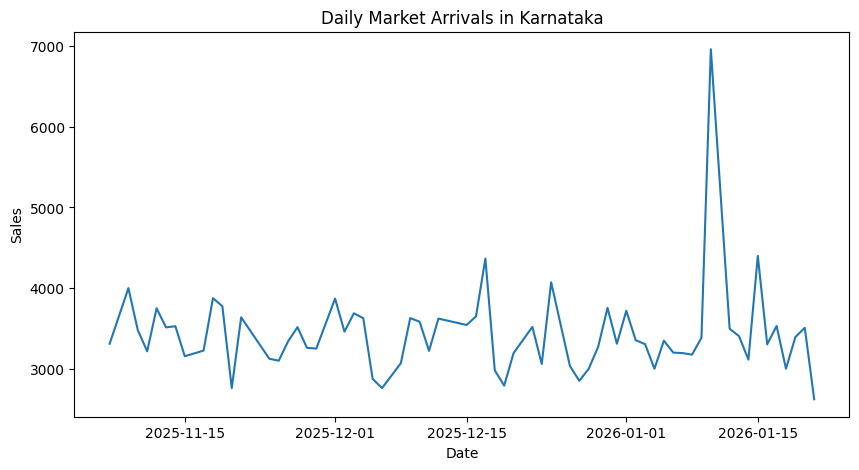

In [ ]:
df_forcast = df_forcast.sort_values(['ds'])

plt.figure(figsize=(10,5))
plt.plot(df_forcast['ds'], df_forcast['y'])
plt.title('Daily Market Arrivals in Karnataka')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()


In [ ]:
# Train–Test Split (Time-Based)
# Last 60 days used for testing.
train = df_forcast.iloc[:-30]
test = df_forcast.iloc[35:]


In [ ]:
from prophet import Prophet
model = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=True
)

model.fit(df_forcast)


In [ ]:
future = model.make_future_dataframe(periods=30,freq='D')
forecast_res = model.predict(future)

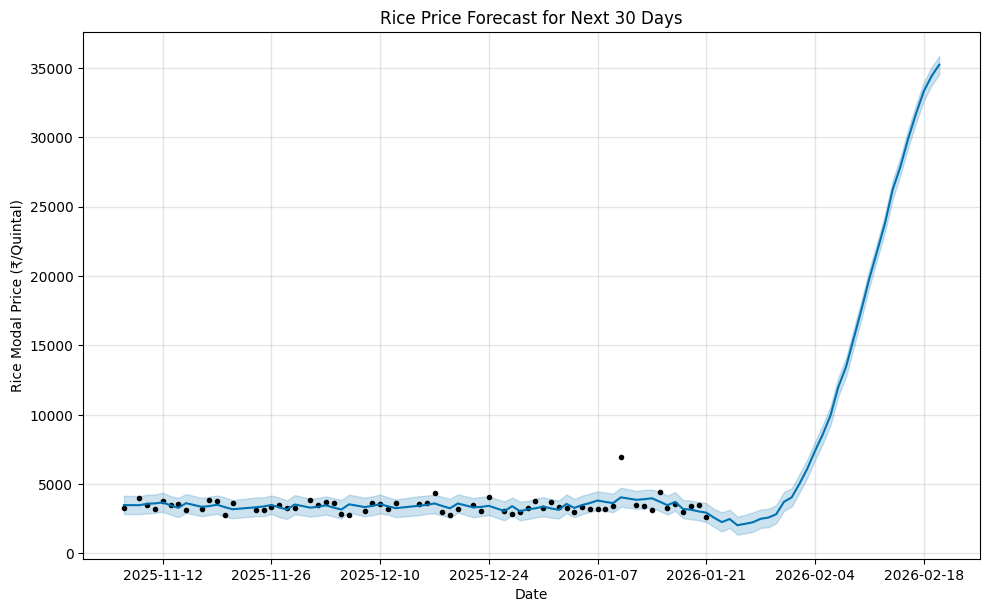

In [ ]:
model.plot(
    forecast_res,
    xlabel='Date',
    ylabel='Rice Modal Price (₹/Quintal)'
)
plt.title('Rice Price Forecast for Next 30 Days')
plt.show()

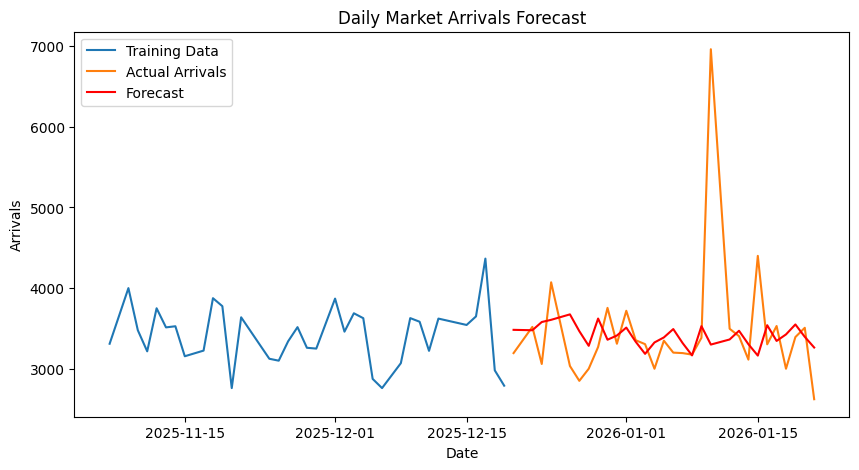

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(train['ds'], train['y'], label='Training Data')
plt.plot(test['ds'], test['y'], label='Actual Arrivals')
plt.plot(test['ds'], forecast_res.iloc[:30]['yhat'], label='Forecast', color='red')
plt.legend()
plt.title('Daily Market Arrivals Forecast')
plt.xlabel('Date')
plt.ylabel('Arrivals')
plt.show()


In [ ]:
y_true = test['y'].values
y_pred = forecast_res.iloc[:30]['yhat'].values

mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
print("MAPE:", round(mape, 2), "%")


MAPE: 10.21 %


In [ ]:
# Daily market prices are:
# Highly volatile
# Influenced by weather, festivals, supply shocks
#  MAPE of 10–20% is considered GOOD